1.load RNAdata

In [ ]:
#读取txt文件（rawdata）

In [7]:
library(dplyr)

In [8]:
BulkRNA_df <- read.table("/storage/public/xuanwenxin/xwx_data/re_jgg/5.count/RNA-Seq_Practice_countstable")
rownames(BulkRNA_df) <- BulkRNA_df$V1
BulkRNA_df <- BulkRNA_df[,2:19]

In [9]:
colnames(BulkRNA_df) <- scan("/storage/public/xuanwenxin/xwx_data/re_jgg/list.txt", what = "character", sep = "\n")
BulkRNA_df <- BulkRNA_df[-1,]
BulkRNA_df[] <- lapply(BulkRNA_df, as.numeric)
head(BulkRNA_df[,1:18],6)

,Cold_HK1,Cold_HK2,Cold_HK3,Cold_SP1,Cold_SP2,Cold_SP3,Cold_TH1,Cold_TH2,Cold_TH3,Ctrl_HK1,Ctrl_HK2,Ctrl_HK3,Ctrl_SP1,Ctrl_SP2,Ctrl_SP3,Ctrl_TH1,Ctrl_TH2,Ctrl_TH3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSONIG00000018423,37,42,36,304,364,281,21,22,40,16,97,19,271,59,403,34,38,20
ENSONIG00000032772,0,3,1,5,4,3,4,3,5,0,4,0,5,5,15,3,1,1
ENSONIG00000007536,0,1,0,1,1,0,0,0,0,0,0,0,0,0,4,0,0,0
ENSONIG00000029674,0,0,1,0,1,0,1,0,0,0,0,0,0,1,1,4,2,0
ENSONIG00000032019,1,0,1,0,0,2,0,1,0,0,2,0,0,0,4,4,5,0
ENSONIG00000033498,59,60,49,51,75,39,48,49,92,13,100,14,85,69,385,88,122,94


In [10]:
featureCounts_meta <- BulkRNA_df[,1:18]
BulkRNA_df <- BulkRNA_df[rowSums(BulkRNA_df)> 0,] 
prefix <- "Tilapia"

In [11]:
RNA_coldata <- data.frame(id = colnames(BulkRNA_df),
                         group = gsub("[0-9]", "", colnames(BulkRNA_df)),
                         condition = stringr::str_split(colnames(BulkRNA_df),pattern = "_",simplify = TRUE)[,1] )

rownames(RNA_coldata) <- RNA_coldata$id
head(RNA_coldata,2)

,id,group,condition
,<chr>,<chr>,<chr>
Cold_HK1,Cold_HK1,Cold_HK,Cold
Cold_HK2,Cold_HK2,Cold_HK,Cold


In [12]:
library(DESeq2)
dds <- DESeqDataSetFromMatrix(countData = BulkRNA_df,
                              colData = RNA_coldata,
                              design = ~ condition)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:clusterProfiler’:

    rename


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object i

In [13]:
tissue <- c("HK","SP","TH")

In [14]:
smallestGroupSize <- 3
keep <- rowSums(counts(dds) >= 10) >= smallestGroupSize
dds <- dds[keep,]

In [15]:
condition_level <- c("Ctrl","Cold")

In [16]:
DESeq_find_diffgenes <- function(sample_id,Col_data,condition_level){
    print(paste("run",sample_id,sep = ":"))
    sample.id <- grep(sample_id,rownames(Col_data),value=T)
    # For sample_id
    dds.sample <- dds[,sample.id]
    colData(dds.sample) <- droplevels(colData(dds.sample))
    dds.sample$condition <- factor(dds.sample$condition, levels = condition_level )
    design(dds.sample) <- formula(~ condition)
    
    dds.sample <- DESeq(dds.sample)
    #res.sample <- results(dds.sample)
    
    # select the genes which showing differentially expressed in any one of HT time points
    temp <- c("condition_Cold_vs_Ctrl")
    lapply(1:length(temp),function(x){
        res1 <- results(dds.sample, name=temp[x])
        res1.ordered <- as.data.frame(res1[order(res1$pvalue),])
        res1.ordered$gene <- rownames(res1.ordered)
        #res1.ordered$condition <- paste0("HT",x)
        res1.ordered$tissue <- sample_id
        return(res1.ordered)
    }) -> res.sample
    res.sample <- do.call(rbind,res.sample)

    res.list <- list(dds.sample,res.sample)
    return(res.list)
}

In [17]:
tissue_deg_list <- lapply(tissue,DESeq_find_diffgenes,Col_data = RNA_coldata,condition_level)
names(tissue_deg_list) <- tissue

[1] "run:HK"


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "run:SP"


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "run:TH"


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [18]:
DEG.RNA <- do.call(rbind,lapply(tissue_deg_list,'[[',2))
DEG.RNA_2 <- na.omit(DEG.RNA) %>% filter(padj < 0.05) %>% group_by(tissue) %>% arrange(desc(log2FoldChange),.by_group = TRUE)
head(DEG.RNA_2)

baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,tissue
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
15.349371,6.732761,1.221477,5.511984,3.548114e-08,1.113293e-06,ENSONIG00000014479,HK
9.273605,5.997890,1.269832,4.723374,2.319638e-06,4.484633e-05,ENSONIG00000042238,HK
8.578649,5.883817,1.290609,4.558946,5.141091e-06,8.950031e-05,ENSONIG00000019199,HK
11.521892,5.544759,1.148675,4.827091,1.385420e-06,2.839257e-05,ENSONIG00000011052,HK
4.971530,5.080199,1.393481,3.645688,2.666774e-04,2.580710e-03,ENSONIG00000008590,HK
4.958700,5.077875,1.386471,3.662446,2.498187e-04,2.442672e-03,ENSONIG00000035414,HK


In [20]:
DEG.RNA_2.list <- split(DEG.RNA_2$gene,DEG.RNA_2$tissue)

In [21]:
geneID_name <- readRDS("/storage/public/xuanwenxin/xwx_data/re_jgg/eggnog_geneID2name.rds")
geneID_name <- geneID_name %>% select(gene = Gene.stable.ID,everything())
geneID_name$eggnog_Preferred_name[is.na(geneID_name$eggnog_Preferred_name)] <- "-"
head(geneID_name,2)

,gene,Gene.name,eggnog_Preferred_name,eggnog_Description
,<chr>,<chr>,<chr>,<chr>
1,ENSONIG00000000001,ppfibp1a,PPFIBP1,"PTPRF interacting protein, binding protein 1 (liprin beta 1)"
2,ENSONIG00000000002,syt10,SYT10,Synaptotagmin X


In [22]:
DEG.RNA_3 <- DEG.RNA_2 %>% group_by(gene) %>% left_join(geneID_name,by = "gene") %>% distinct()

Warning message in left_join(., geneID_name, by = "gene"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 86 of `x` matches multiple rows in `y`.
ℹ Row 4545 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.”


Venn Plot

In [23]:
library(ggvenn)

Loading required package: ggplot2



In [24]:
options(repr.plot.width = 6,repr.plot.height = 6)
RNA_venn <- ggvenn(
  data = DEG.RNA_2.list[c("HK","TH","SP")],         # 数据列表
  columns = c("HK","TH","SP"),           # 对选中的列名绘图，最多选择4个，NULL为默认全选
  show_elements = F,        # 当为TRUE时，显示具体的交集情况，而不是交集个数
  label_sep = "\n",         # 当show_elements = T时生效，分隔符 \n 表示的是回车的意思
  show_percentage = T,      # 显示每一组的百分比
  digits = 1,               # 百分比的小数点位数
  fill_color = c("#A5C496", "#C7988C", "#8891DB"), # 填充颜色
  fill_alpha = .6,         # 填充透明度
  stroke_color = "black",   # 边缘颜色
  stroke_alpha = 0.9,       # 边缘透明度
  stroke_size = 0.2,        # 边缘粗细
  stroke_linetype = "solid", # 边缘线条 # 实线：solid  虚线：twodash longdash 点：dotdash dotted dashed  无：blank
  set_name_color = "black", # 组名颜色
  set_name_size = 6,        # 组名大小
  text_color = "black",     # 交集个数颜色
  text_size = 5             # 交集个数文字大小
)

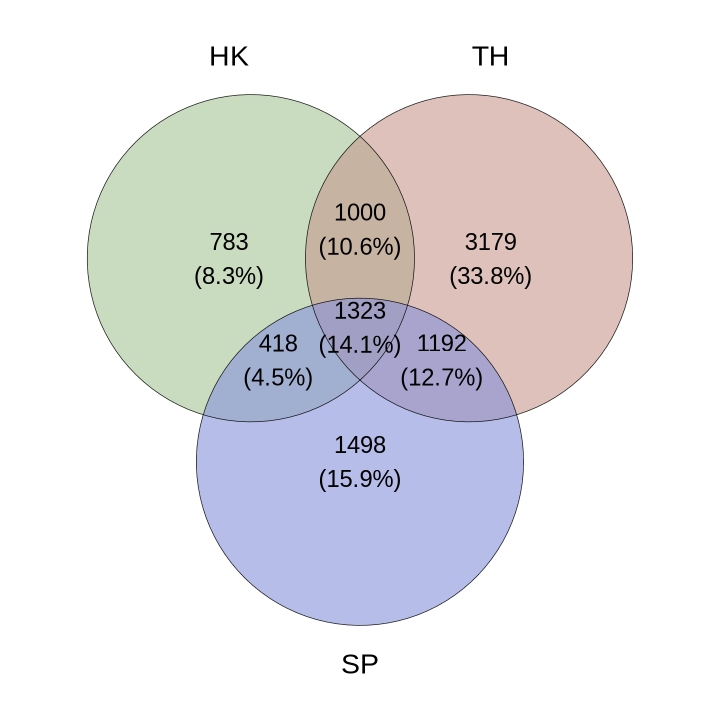

In [25]:
RNA_venn

PCA

In [26]:
#stabilize varaince within libraries
dds <- estimateSizeFactors(dds)
dds <- estimateDispersions(dds)
vsd <- vst(dds)
vsd_filtered <- assay(vsd)

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



In [27]:
options(repr.plot.width = 6,repr.plot.height = 5)
RNA_PCA_plot <- plotPCA(vsd[,grep(colnames(vsd),pattern = "SP",invert = T)], intgroup='group', ntop=1000) + 
    ggsci::scale_color_npg() + 
    theme_classic(base_size = 15) + 
    theme(axis.line = element_blank(),
          panel.border = element_rect(fill=NA,color="black", size=1, linetype="solid"))

using ntop=1000 top features by variance

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the DESeq2 package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [28]:
temp <- RNA_PCA_plot$data
temp$treat <- stringr::str_split(temp$group,pattern = "_",simplify = T)[,1]
temp$tissue <- stringr::str_split(temp$group,pattern = "_",simplify = T)[,2]
temp$treat <- factor(temp$treat,levels = c("Ctrl","Cold"))

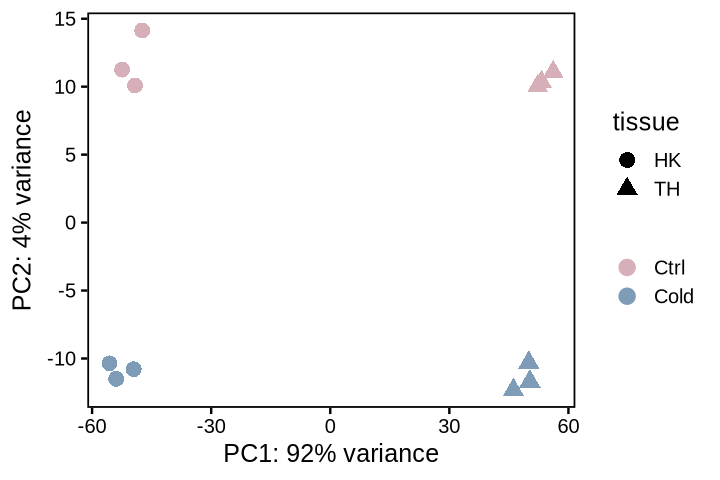

In [29]:
options(repr.plot.width = 6,repr.plot.height = 4)
ggplot(temp,aes(x = PC1 , y = PC2 ,color = treat,shape = tissue)) + 
    geom_point(size = 4) + scale_color_manual(values = c("#D6AFB9","#7E9BB7")) +
    labs(x = "PC1: 92% variance",y = "PC2: 4% variance" , color = NULL) +
    theme_classic(base_size = 15) + 
    theme(axis.line = element_blank(),panel.border = element_rect(fill=NA,color="black", size=1, linetype="solid"))

using ntop=1000 top features by variance



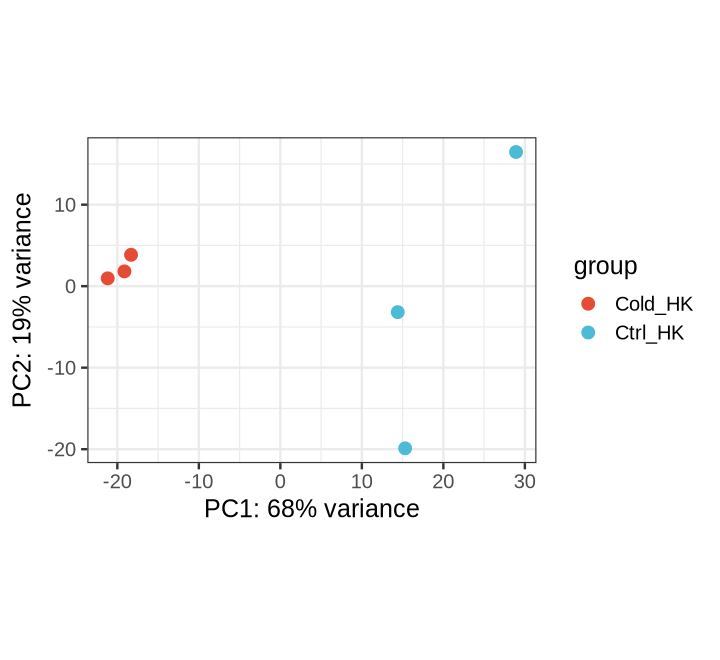

In [30]:
options(repr.plot.width = 6,repr.plot.height = 5.5)
plotPCA(vsd[,grep(colnames(vsd),pattern = "HK")], intgroup='group', ntop=1000) + ggsci::scale_color_npg() + theme_bw(base_size = 15)

In [31]:
pca_function <- function(data){
    mydata<-as.data.frame(t(data))
    mydata=vegan::decostand(mydata,method = "hellinger")
    otu_pca<- prcomp(mydata,scal=F)
    pc12 <- as.data.frame(otu_pca$x[,1:2])*100
    pc12$samples<-rownames(pc12)
    return(pc12)
                             }

In [32]:
library(ggrepel)

In [33]:
pc12 <- pca_function(data = vsd_filtered)
pc12$treat <- gsub("[1-9]","",pc12$samples)
pc12$tissue <- stringr::str_split(pc12$samples,pattern = "_",simplify = T)[,2]

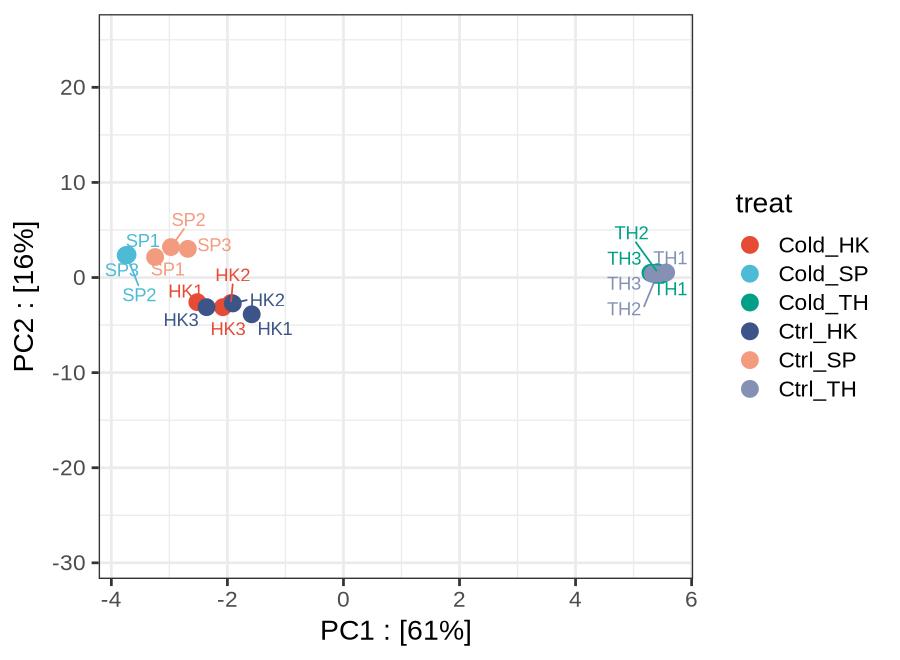

In [34]:
options(repr.plot.width = 7.5,repr.plot.height = 5.5)
ggplot(data = pc12,aes(x = PC1,y = PC2,col = treat)) + 
    geom_point(size = 4) + 
    geom_text_repel(data = pc12,aes(x = PC1,y = PC2,label = tissue),show.legend = F,direction = "both",max.overlaps = 15) +
    ggsci::scale_color_npg() +
    ylim(c(-29,25)) +
    theme_bw(base_size = 17) + labs(x = "PC1 : [61%]", y = "PC2 : [16%]") 

### Heatmap

In [35]:
library(ComplexHeatmap)

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [36]:
DEGs <- DEG.RNA_2 %>% filter(tissue != "SP") %>% .$gene %>% unique

In [37]:
BulkRNA_df2 <- BulkRNA_df[,grep(names(BulkRNA_df),pattern = "SP",invert = T)] %>% dplyr::select(7:9,1:3,10:12,4:6)

In [38]:
scale_row <- function(x){
    m = apply(x, 1, mean, na.rm = T)
    s = apply(x, 1, sd, na.rm = T)
    return((x - m) / s)
}

In [39]:
BulkRNA_df.scale <- BulkRNA_df2[DEGs,] %>% na.omit
BulkRNA_df.scale[,1:6] <- scale_row(BulkRNA_df.scale[,1:6])
BulkRNA_df.scale[,7:12] <- scale_row(BulkRNA_df.scale[,7:12])

In [40]:
BulkRNA_df.scale2 <- BulkRNA_df.scale[complete.cases(BulkRNA_df.scale), ]

In [41]:
mat <- vst(dds, blind=FALSE) %>% assay

In [42]:
mat2 <- mat[,grep(colnames(mat),pattern = "SP",invert = T)]

In [43]:
mat2 <- mat2[,c(7:9,1:3,10:12,4:6)]

In [44]:
mat2.scale <- mat2[DEGs,]
mat2.scale[,1:6] <- scale_row(mat2.scale[,1:6])
mat2.scale[,7:12] <- scale_row(mat2.scale[,7:12])

In [45]:
mat2.scale2 <- mat2.scale[complete.cases(mat2.scale), ]

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



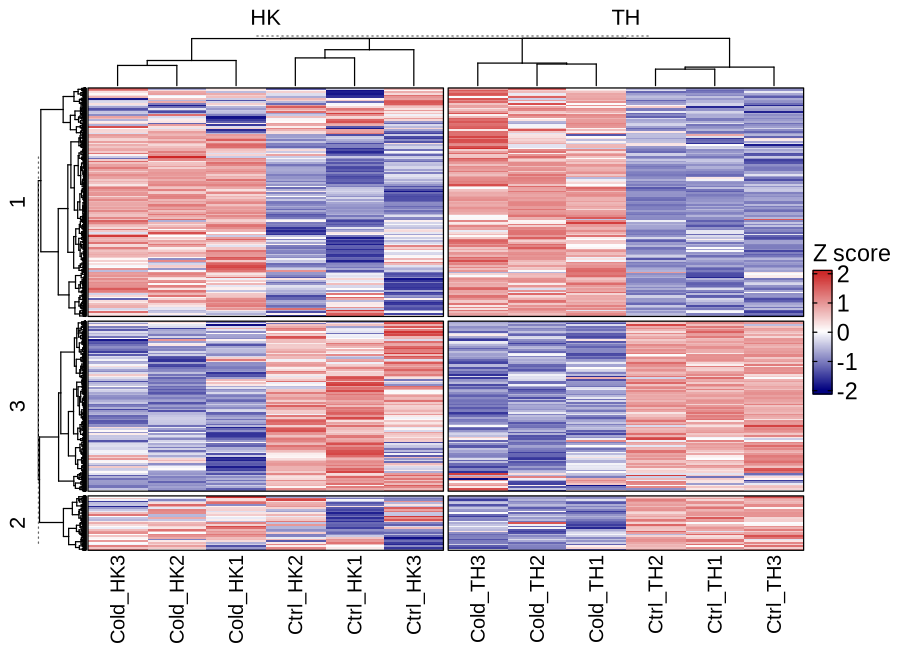

In [46]:
vst.heatmap <- Heatmap(mat2.scale2,
        col = colorRampPalette(c("navy","white","firebrick3"))(100),
        clustering_distance_rows = function(m) dist(m),
        clustering_method_rows = "ward.D2",
        row_km = 3,
        use_raster = TRUE,
        border = TRUE,
        column_split = factor( rep(c("HK","TH"), each = 6)),
        heatmap_legend_param = list(
             title='Z score',
             title_gp = gpar(fontsize = 14),
             labels_gp = gpar(fontsize = 14),
             border='black'),
        show_row_names = FALSE)
vst.heatmap2 <- draw(vst.heatmap)

In [47]:
cluster_gene <- do.call(rbind, lapply(names( row_order(vst.heatmap2) ) , function(name) {
      data.frame(cluster = name, gene = rownames(mat2.scale2)[ row_order(vst.heatmap2)[[name]] ], stringsAsFactors = FALSE)
}))

In [48]:
#table(cluster_gene$gene) 获取row_cluster相关信息
row_cluster <- c( rep("cluster3",times = 932),
  rep("cluster2",times = 3317),
  rep("cluster1",times = 3611))
row_cluster <- factor(row_cluster,levels = c("cluster1","cluster2","cluster3"))

In [70]:
cluster_gene

cluster,gene
<chr>,<chr>
1,ENSONIG00000005810
1,ENSONIG00000043105
1,ENSONIG00000039702
1,ENSONIG00000032392
1,ENSONIG00000010264
1,ENSONIG00000015915
1,ENSONIG00000039801
1,ENSONIG00000020173
1,ENSONIG00000028785


In [49]:
 library(dplyr)

TF enrichment

In [50]:
#From biomart
TF_fam <- read.table("/home/xuanwenxin/xwx_data/re_jgg/GO_KEGG_database/Oreochromis_niloticus_TF.txt",
                     sep = "\t",header = TRUE)

In [51]:
TF_fam_2 <- TF_fam[,c(3,4)] %>% distinct() %>% arrange(Family) %>% dplyr::select(term = Family,gene = Ensembl)

In [52]:
library(clusterProfiler)

In [53]:
lapply(split(cluster_gene$gene,f = cluster_gene$cluster) ,function(genes){
    genes2 <- genes[genes %in% TF_fam_2$gene]#挑选是TF的DEGs
    print(c("TF Num :",length(genes2)))
    res <- enricher(gene = genes2,TERM2GENE = TF_fam_2,pAdjustMethod = "BH",minGSSize = 3)
    return(res)
}) -> TF_enrich_res

names(TF_enrich_res) <- paste("cluster",names(split(cluster_gene$gene,f = cluster_gene$cluster)),sep = "")

[1] "TF Num :" "362"     
[1] "TF Num :" "73"      
[1] "TF Num :" "187"     


In [54]:
lapply(names(TF_enrich_res),function(x){
    x2 <- TF_enrich_res[[x]]@result
    x2$cluster <- x
    return(x2)
}) -> TF_enrich_res_list
TF_enrich_res_df <- do.call(rbind,TF_enrich_res_list)

In [55]:
setwd("/home/xuanwenxin/xwx_data/re_jgg/output/enrichment")

In [56]:
openxlsx::write.xlsx(TF_enrich_res_df,
                     "BulkRNA_TF_enrichment.xlsx")

In [57]:
TF_enrich_res_df_filter <- TF_enrich_res_df %>% 
    filter(p.adjust < 0.05) %>% group_by(cluster) %>% 
    arrange(p.adjust,.by_group = TRUE) %>% ungroup

In [58]:
openxlsx::write.xlsx(TF_enrich_res_df_filter,
                     "BulkRNA_TF_enrichment_filter.xlsx")

In [ ]:
GO enrichment

In [59]:
#GO_KEGG富集分析相关函数
enrichment_stat_go = function(bl,il) {
#  gos <- gene_go2
#  go_des <- go_des
  gos.bl <- gos[gos$gene %in% bl,]
  gos.il <- gos[gos$gene %in% il,]
  gos.bl.stat <- gos.bl %>% group_by(GO) %>% dplyr::summarise(GeneNumber=n()) %>% ungroup
  gos.il.stat <- gos.il %>% group_by(GO) %>% dplyr::summarise(GeneNumber=n()) %>% ungroup
  list.df <- gos.bl.stat %>% group_by(GO) %>% left_join(gos.il.stat,by="GO") %>% ungroup
  list.df[is.na(list.df)] <- 0
  names(list.df) <- c("GO","k","x")#k:bl x:il
  list.df$m = as.numeric(length(unique(sort(gos.il$gene))))
  list.df$n = as.numeric(length(unique(sort(gos.bl$gene))))-list.df$k
  list.df$Pvalue <- apply(list.df[,-1],1,FUN=function(x) {phyper(x[2]-1,x[1],x[4],x[3],lower.tail=F)})
  # if (id == "go"){
  #   list <- list[list$class == "biological_process" & list$k >= 10,]
  # }
  
  #list$p.adjust <- p.adjust(list$Pvalue,method="fdr",n=length(list$Pvalue))
  list.df <- list.df[order(list.df$Pvalue,decreasing=F),]
  list.df$fold = list.df$x*(list.df$n+list.df$k)/list.df$m/list.df$k ## should add fold enrichment value
  list.1 <- list.df %>% group_by(GO) %>% left_join(go_des,by="GO") %>% ungroup
  list.1 <- list.1[list.1$k>=10 & list.1$x>=3,]
  list.1$p.adjust <- p.adjust(list.1$Pvalue,method="fdr",n=length(list.1$Pvalue))
  list.1 <- list.1[list.1$Pvalue < 0.05,]
  list.1
}

enrichment_stat_kegg = function(bl,il) {
#  keggs <- keggs
#  kegg_des <- kegg_des
  
  keggs.bl <- keggs[keggs$gene %in% bl,]
  keggs.il <- keggs[keggs$gene %in% il,]
  keggs.bl.stat <- keggs.bl %>% group_by(kegg) %>% dplyr::summarise(GeneNumber=n()) %>% ungroup
  keggs.il.stat <- keggs.il %>% group_by(kegg) %>% dplyr::summarise(GeneNumber=n()) %>% ungroup
  list.df <- keggs.bl.stat %>% group_by(kegg) %>% left_join(keggs.il.stat,by="kegg") %>% ungroup
  list.df[is.na(list.df)]<-0
  names(list.df) <- c("kegg","k","x")
  list.df$m = as.numeric(length(unique(sort(keggs.il$gene))))
  list.df$n = as.numeric(length(unique(sort(keggs.bl$gene))))-list.df$k
  list.df$Pvalue <- apply(list.df[,-1],1,FUN=function(x) {phyper(x[2]-1,x[1],x[4],x[3],lower.tail=F)})
  # if (id == "kegg"){
  #   list <- list[list$class == "biological_process" & list$k >= 10,]
  # }
  
  #list.df$p.adjust <- p.adjust(list.df$Pvalue,method="fdr",n=length(list.df$Pvalue))
  list.df <- list.df[order(list.df$Pvalue,decreasing=F),]
  list.df$fold = list.df$x*(list.df$n+list.df$k)/list.df$m/list.df$k ## should add fold enrichment value
  list.1 <- list.df %>% group_by(kegg) %>% left_join(kegg_des,by="kegg") %>% ungroup
  list.1 <- list.1[list.1$k>=10 & list.1$x>=2,]
  list.1$p.adjust <- p.adjust(list.1$Pvalue,method="fdr",n=length(list.1$Pvalue))
  list.1 <- list.1[list.1$Pvalue < 0.05,]
  list.1
}

In [60]:
load("/home/xuanwenxin/xwx_data/re_jgg/GO_KEGG_database/go_info.RData")
load("/home/xuanwenxin/xwx_data/re_jgg/GO_KEGG_database/kegg_info.RData")

In [61]:
lapply(split(cluster_gene$gene,f = cluster_gene$cluster),function(x){
    GO_res <- enrichment_stat_go(bl = rownames(mat2),il = x)
    return(GO_res)
}) -> GO_res

In [62]:
names(GO_res) <- paste("cluster",names(split(cluster_gene$gene,f = cluster_gene$cluster)),sep = "")

In [63]:
openxlsx::write.xlsx(GO_res,
                     "/home/xuanwenxin/xwx_data/re_jgg/output/enrichment/Heatmap_cluster_gene_GO.xlsx")

In [64]:
head(geneID_name)
geneID_name_uniq <- geneID_name %>% group_by(gene) %>% dplyr::slice(1) %>% ungroup
head(geneID_name_uniq)

,gene,Gene.name,eggnog_Preferred_name,eggnog_Description
,<chr>,<chr>,<chr>,<chr>
1,ENSONIG00000000001,ppfibp1a,PPFIBP1,"PTPRF interacting protein, binding protein 1 (liprin beta 1)"
2,ENSONIG00000000002,syt10,SYT10,Synaptotagmin X
3,ENSONIG00000000002,syt10,CYB5R3,b5 reductase
4,ENSONIG00000000003,syt1a,SYT1,Synaptotagmin Ia
5,ENSONIG00000000005,ppp1r12a,PPP1R12A,Protein phosphatase 1 regulatory
6,ENSONIG00000000006,rps16,RPS16,Belongs to the universal ribosomal protein uS9 family


gene,Gene.name,eggnog_Preferred_name,eggnog_Description
<chr>,<chr>,<chr>,<chr>
ENSONIG00000000001,ppfibp1a,PPFIBP1,"PTPRF interacting protein, binding protein 1 (liprin beta 1)"
ENSONIG00000000002,syt10,SYT10,Synaptotagmin X
ENSONIG00000000003,syt1a,SYT1,Synaptotagmin Ia
ENSONIG00000000005,ppp1r12a,PPP1R12A,Protein phosphatase 1 regulatory
ENSONIG00000000006,rps16,RPS16,Belongs to the universal ribosomal protein uS9 family
ENSONIG00000000007,myf6,MYF6,Myogenic factor 6


In [65]:
library(dplyr)
lapply(split(cluster_gene$gene,f = cluster_gene$cluster),function(x){
    GO_res <- enrichment_stat_go(bl = rownames(mat2),il = x)
    
    gos2 <- gos %>% group_by(gene)  %>% left_join(geneID_name_uniq,by = "gene") %>% ungroup
    
    GO_gene <- gos2[gos2$gene %in% x,] %>% group_by(GO) %>% summarise(gene = paste(gene,collapse = "/"),
                                                                      Gene.name = paste(Gene.name,collapse = "/"),
                                                                      eggnog_Preferred_name = paste(eggnog_Preferred_name,collapse = "/")
                                                                     ) %>% ungroup
    
    GO_res2 <- GO_res %>% left_join(GO_gene,by = "GO")
    return(GO_res2)
}) -> GO_res

In [66]:
names(GO_res) <- paste("cluster",names(split(cluster_gene$gene,f = cluster_gene$cluster)),sep = "")

In [67]:
setwd("/home/xuanwenxin/xwx_data/re_jgg/output/enrichment")

In [69]:
openxlsx::write.xlsx(GO_res,
                     "Heatmap_cluster_gene_GO.xlsx")

Warning message in wb$writeData(df = x, colNames = colNames, sheet = sheet, startCol = startCol, :
“0016435/ENSONIG0 ... SONIG00000042622 is truncated. 
Number of characters exeed the limit of 32767.”
Warning message in wb$writeData(df = x, colNames = colNames, sheet = sheet, startCol = startCol, :
“0014273/ENSONIG0 ... SONIG00000033068 is truncated. 
Number of characters exeed the limit of 32767.”
Warning message in wb$writeData(df = x, colNames = colNames, sheet = sheet, startCol = startCol, :
“0003748/ENSONIG0 ... SONIG00000033068 is truncated. 
Number of characters exeed the limit of 32767.”
Warning message in wb$writeData(df = x, colNames = colNames, sheet = sheet, startCol = startCol, :
“0012314/ENSONIG0 ... SONIG00000042622 is truncated. 
Number of characters exeed the limit of 32767.”
Warning message in wb$writeData(df = x, colNames = colNames, sheet = sheet, startCol = startCol, :
“0019718/ENSONIG0 ... SONIG00000042622 is truncated. 
Number of characters exeed the limit of 327